# 🏅 Analyse des athlètes olympiques
### Nettoyage, préparation et exploration du dataset  
Ce notebook a pour objectif de :
- Nettoyer et préparer les données  
- Corriger les incohérences  
- Traiter les valeurs manquantes  
- Créer de nouvelles variables utiles (IMC)  
- Réaliser une analyse descriptive et visuelle  

In [26]:
import pandas as pd
df=pd.read_csv('athlete_events.csv')
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  str    
 2   Sex     271116 non-null  str    
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  str    
 7   NOC     271116 non-null  str    
 8   Games   271116 non-null  str    
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  str    
 11  City    271116 non-null  str    
 12  Sport   271116 non-null  str    
 13  Event   271116 non-null  str    
 14  Medal   39783 non-null   str    
dtypes: float64(3), int64(2), str(10)
memory usage: 31.0 MB


In [28]:
df.describe()

,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


# **Get duplicated rows

In [29]:
duplicates = df[df.duplicated()]
duplicates

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
1252,704,Dsir Antoine Acket,M,27.0,NaN,NaN,Belgium,BEL,1932 Summer,1932,Summer,Los Angeles,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",NaN
4282,2449,William Truman Aldrich,M,48.0,NaN,NaN,United States,USA,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Painting, Drawings And ...",NaN
4283,2449,William Truman Aldrich,M,48.0,NaN,NaN,United States,USA,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Painting, Drawings And ...",NaN
4862,2777,Hermann Reinhard Alker,M,43.0,NaN,NaN,Germany,GER,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Architecture, Designs F...",NaN
4864,2777,Hermann Reinhard Alker,M,43.0,NaN,NaN,Germany,GER,1928 Summer,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Architecture, Architect...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269994,135072,Anna Katrina Zinkeisen (-Heseltine),F,46.0,NaN,NaN,Great Britain,GBR,1948 Summer,1948,Summer,London,Art Competitions,"Art Competitions Mixed Painting, Paintings",NaN
269995,135072,Anna Katrina Zinkeisen (-Heseltine),F,46.0,NaN,NaN,Great Britain,GBR,1948 Summer,1948,Summer,London,Art Competitions,"Art Competitions Mixed Painting, Paintings",NaN
269997,135072,Anna Katrina Zinkeisen (-Heseltine),F,46.0,NaN,NaN,Great Britain,GBR,1948 Summer,1948,Summer,London,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",NaN
269999,135073,Doris Clare Zinkeisen (-Johnstone),F,49.0,NaN,NaN,Great Britain,GBR,1948 Summer,1948,Summer,London,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",NaN


# **Drop duplicates**

In [30]:
df.drop_duplicates(inplace=True)

# **Finding inconsistent categories**

In [31]:


valid_medal = {"Gold", "Bronze", "Silver"}

categories = {
    "Medal": valid_medal
}



In [32]:
observed = set(df["Medal"].astype(str).str.strip().str.title().unique())

inconsistent_categories = observed - categories["Medal"]
print(inconsistent_categories)


{nan}


In [33]:
df['Medal'] = df['Medal'].fillna("No medal")

In [34]:
df['Season'].unique()

<StringArray>
['Summer', 'Winter']
Length: 2, dtype: str

# Replacing  missing values in Height	Weight with the median

In [35]:
Height_Median=df['Height'].median()
Weight_Median=df['Weight'].median()
df=df.fillna({'Height':Height_Median,'Weight':Weight_Median})
df.head(10)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No medal
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No medal
2,3,Gunnar Nielsen Aaby,M,24.0,175.0,70.0,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,No medal
3,4,Edgar Lindenau Aabye,M,34.0,175.0,70.0,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,No medal
5,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",No medal
6,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,No medal
7,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,"Speed Skating Women's 1,000 metres",No medal
8,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,Speed Skating Women's 500 metres,No medal
9,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,"Speed Skating Women's 1,000 metres",No medal


In [39]:
# 1. Calcul de IMC
df["Height_m"] = df["Height"] / 100
df["IMC"] = df["Weight"] / (df["Height_m"]**2)
df = df.drop(columns=["Height_m"])

# 2. Extraire la colonne IMC AVANT d'effacer l'ancienne
imc_col = df["IMC"].copy()

# 3. Supprimer IMC s'il existe déjà
df = df.drop(columns=["IMC"], errors="ignore")

# 4. Insérer IMC en position 4
df.insert(4, "IMC", imc_col)
# 5.Supprimer Height and Weight 
df=df.drop(columns=['Height','Weight',])
df.head()

,ID,Name,Sex,Age,IMC,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,24.691358,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No medal
1,2,A Lamusi,M,23.0,20.761246,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No medal
2,3,Gunnar Nielsen Aaby,M,24.0,22.857143,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,No medal
3,4,Edgar Lindenau Aabye,M,34.0,22.857143,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,23.959094,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,No medal


Drop Games and Team column

In [40]:
df = df.drop(columns=['Games','Team'])

In [41]:
print(df.columns.tolist())

['ID', 'Name', 'Sex', 'Age', 'IMC', 'NOC', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal']


In [44]:
df=df.sort_values(by=['Age','Year'],ascending=[False,True],na_position='first')
df=df.reset_index(drop=True)

In [43]:
df.head()

,ID,Name,Sex,Age,IMC,NOC,Year,Season,City,Sport,Event,Medal
0,1724,Aristidis Akratopoulos,M,NaN,22.857143,GRE,1896,Summer,Athina,Tennis,Tennis Men's Singles,No medal
1,1724,Aristidis Akratopoulos,M,NaN,22.857143,GRE,1896,Summer,Athina,Tennis,Tennis Men's Doubles,No medal
2,1725,"Konstantinos ""Kostas"" Akratopoulos",M,NaN,22.857143,GRE,1896,Summer,Athina,Tennis,Tennis Men's Singles,No medal
3,1725,"Konstantinos ""Kostas"" Akratopoulos",M,NaN,22.857143,GRE,1896,Summer,Athina,Tennis,Tennis Men's Doubles,No medal
4,4113,Anastasios Andreou,M,NaN,22.857143,GRE,1896,Summer,Athina,Athletics,Athletics Men's 110 metres Hurdles,No medal


# Drop missing Values

In [46]:
df=df.dropna(subset=['Age'])
df["Age"] = df["Age"].astype(int)
df.head()

,ID,Name,Sex,Age,IMC,NOC,Year,Season,City,Sport,Event,Medal
9315,128719,John Quincy Adams Ward,M,97,22.857143,USA,1928,Summer,Amsterdam,Art Competitions,"Art Competitions Mixed Sculpturing, Statues",No medal
9316,49663,Winslow Homer,M,96,22.857143,USA,1932,Summer,Los Angeles,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",No medal
9317,31173,Thomas Cowperthwait Eakins,M,88,22.857143,USA,1932,Summer,Los Angeles,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",No medal
9318,5146,George Denholm Armour,M,84,22.857143,GBR,1948,Summer,London,Art Competitions,"Art Competitions Mixed Painting, Unknown Event",No medal
9319,118789,Louis Tauzin,M,81,22.857143,FRA,1924,Summer,Paris,Art Competitions,Art Competitions Mixed Sculpturing,No medal


In [51]:
import matplotlib.pyplot as plt

In [67]:
medal_df=df[df['Medal'].isin(['Gold','Silver','Bronze'])]
counts=medal_df['Sex'].value_counts()
percentages=(counts/counts.sum())*100

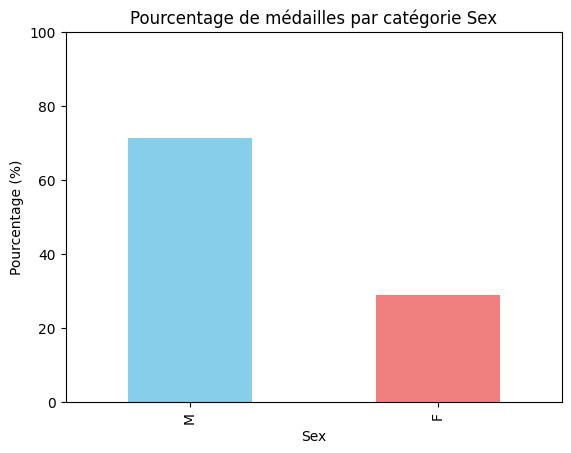

In [68]:
percentages.plot(kind='bar',color=['skyblue','lightcoral'])
plt.title("Pourcentage de médailles par catégorie Sex")
plt.xlabel("Sex")
plt.ylabel("Pourcentage (%)")
plt.ylim(0,100)
plt.show()

##  Analyse du pourcentage de médailles par catégorie Sex

Le graphique ci‑dessus présente la répartition des médailles entre les athlètes masculins (M) et féminins (F).  
Il s’agit d’un pourcentage calculé uniquement sur les athlètes ayant remporté une médaille (Gold, Silver ou Bronze).

###  Interprétation

- Les athlètes **masculins** représentent **la majorité des médaillés**, avec un pourcentage d’environ **70 %**.
- Les athlètes **féminins** représentent environ **30 %** des médaillé(e)s.

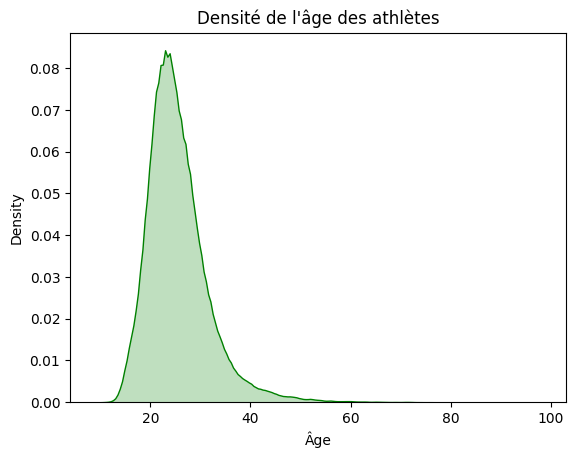

In [71]:
sns.kdeplot(df["Age"], fill=True, color="green")
plt.title("Densité de l'âge des athlètes")
plt.xlabel("Âge")
plt.show()

##  Analyse de la densité de l'âge des athlètes

Le graphique de densité ci‑dessus représente la distribution des âges des athlètes olympiques.  


###  Interprétation

- La **majorité des athlètes** se situent entre **18 et 30 ans**, avec un **pic clair autour de 20–25 ans**.  
  Cela correspond à la période optimale de performance physique, ce qui explique la forte concentration dans cette tranche d’âge.

- La distribution est **asymétrique** (*skewed à droite*) :  
  la densité diminue progressivement après 30 ans.  
  Cela montre que **les athlètes plus âgés sont beaucoup moins nombreux**.

- Quelques valeurs existent au‑delà de **40, 50 voire 80 ans**, mais elles représentent des **cas très rares**.  
  Ces âges élevés correspondent généralement à des disciplines particulières (ex : sports artistiques, tir, équitation, anciens Jeux comportant des épreuves artistiques).

###  Conclusion

L'âge typique d'un athlète olympique se situe autour de **20–25 ans**, avec une faible représentation des athlètes au‑delà de 35 ans.  
Ce profil jeune reflète les exigences physiques de la grande majorité des disciplines olympiques.

In [53]:
import seaborn as sns

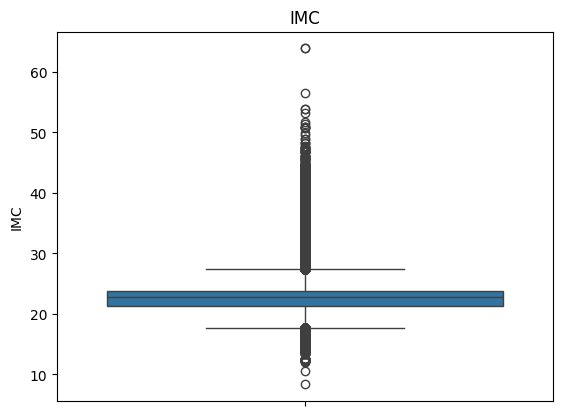

In [63]:
sns.boxplot(df["IMC"]).set_title("IMC");




##  Analyse du boxplot de l'IMC des athlètes

Ce boxplot représente la distribution de l’IMC (Indice de Masse Corporelle) de l’ensemble des athlètes présents dans le dataset.  
Il permet d’identifier la tendance centrale, la dispersion des valeurs, ainsi que la présence de valeurs aberrantes (*outliers*).


Le boxplot de l’IMC met en évidence une distribution globalement cohérente avec les caractéristiques physiques attendues des athlètes olympiques, mais aussi une quantité non négligeable de valeurs extrêmes.  
Ces outliers nécessitent une vérification ou un traitement pour garantir la qualité des analyses statistiques ultérieures.


#  Calculer les limites d’outliers

In [55]:
Q1 = df["IMC"].quantile(0.25)
Q3 = df["IMC"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Limite basse :", lower_bound)
print("Limite haute :", upper_bound)

Limite basse : 17.744873777978313
Limite haute : 27.379331957749002


# Filtrer les valeurs aberrantes

In [56]:
df_no_outliers = df[(df["IMC"] >= lower_bound) & (df["IMC"] <= upper_bound)]

In [57]:
print("Avant :", len(df))
print("Après :", len(df_no_outliers))
print("Supprimés :", len(df) - len(df_no_outliers))

Avant : 260416
Après : 244326
Supprimés : 16090


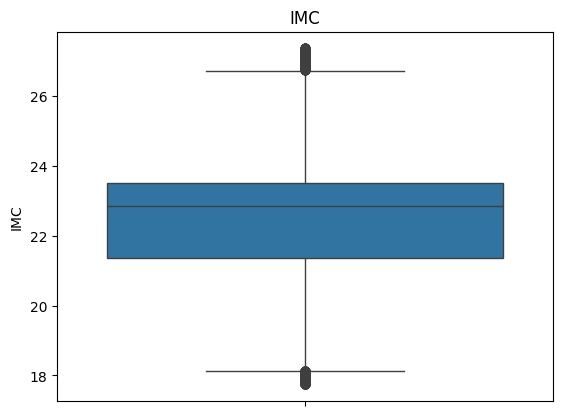

In [65]:
sns.boxplot(df_no_outliers["IMC"]).set_title("IMC");


##  Analyse du boxplot de l’IMC (après suppression des outliers)

Ce boxplot représente la distribution de l’Indice de Masse Corporelle (IMC) des athlètes après traitement et suppression des valeurs aberrantes. L’objectif est de mieux visualiser la tendance centrale réelle et la dispersion sans être influencé par les extrêmes.

###  Interprétation

- La **médiane** de l’IMC se situe légèrement au‑dessus de **22**, ce qui signifie que la moitié des athlètes ont un IMC inférieur à cette valeur.
- La **boîte** (intervalle interquartile) est relativement étroite : la majorité des athlètes ont un IMC compris **entre 21 et 24**.  
  → Cela montre une **faible variabilité**, ce qui est cohérent avec des profils physiques relativement homogènes.
- Les **moustaches** montrent une dispersion allant d’environ **18 à 27**, ce qui reste dans des valeurs physiologiquement normales pour des sportifs.
- Les quelques points isolés visibles aux extrémités représentent les **derniers outliers restants**, mais beaucoup moins nombreux qu’avant nettoyage.

###  Conclusion

La distribution nettoyée de l’IMC révèle un profil typique d’athlète olympique :  
un IMC généralement situé entre **21 et 24**, indiquant une morphologie sportive standard (ni excès pondéral, ni sous‑poids important).  
Le nettoyage a permis de mieux mettre en évidence cette structure centrale tout en réduisant l’impact des valeurs extrêmes.

 ## Nombre de médailles par équipe (Team)

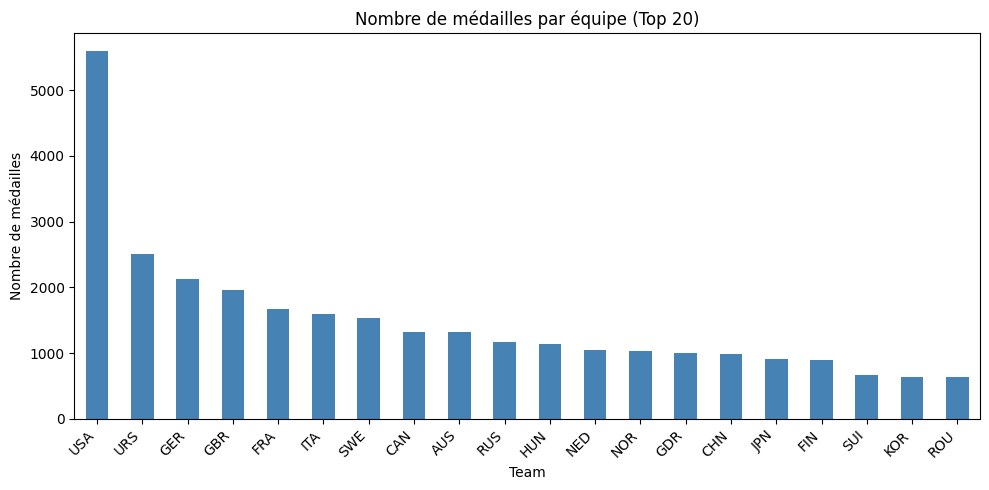

In [69]:
#compter les medailles par Team
counts = medal_df.groupby('NOC')['Medal'].count().sort_values(ascending=False)
#Afficher le top N
N=20
top_counts=counts.head(N)
plt.figure(figsize=(10,5))
top_counts.plot(kind='bar',color='steelblue')

plt.title(f"Nombre de médailles par équipe (Top {N})")
plt.xlabel("Team")
plt.ylabel("Nombre de médailles")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



In [70]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 260416 entries, 9315 to 269730
Data columns (total 12 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      260416 non-null  int64  
 1   Name    260416 non-null  str    
 2   Sex     260416 non-null  str    
 3   Age     260416 non-null  int64  
 4   IMC     260416 non-null  float64
 5   NOC     260416 non-null  str    
 6   Year    260416 non-null  int64  
 7   Season  260416 non-null  str    
 8   City    260416 non-null  str    
 9   Sport   260416 non-null  str    
 10  Event   260416 non-null  str    
 11  Medal   260416 non-null  str    
dtypes: float64(1), int64(3), str(8)
memory usage: 23.8 MB


,ID,Age,IMC,Year
count,260416.000000,260416.000000,260416.000000,260416.000000
mean,68302.983645,25.454776,22.812466,1980.328820
std,39001.549258,6.163869,2.638582,28.496924
min,1.000000,10.000000,8.360954,1896.000000
25%,34761.750000,21.000000,21.357796,1964.000000
50%,68224.000000,24.000000,22.857143,1988.000000
75%,102120.250000,28.000000,23.766410,2004.000000
max,135571.000000,97.000000,63.901580,2016.000000
